<a href="https://colab.research.google.com/github/Japjotongithub/Crime-Pattern-Analysis/blob/main/Crime_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Crime Pattern Analysis and Prediction in India

## Import required libraries and data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/crime_dataset_india.csv")
df.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Report Number,Date Reported,Date of Occurrence,Time of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,Case Closed,Date Case Closed
0,1,02-01-2020 00:00,01-01-2020 00:00,01-01-2020 01:11,Ahmedabad,576,IDENTITY THEFT,16,M,Blunt Object,Violent Crime,13,No,NaN
1,2,01-01-2020 19:00,01-01-2020 01:00,01-01-2020 06:26,Chennai,128,HOMICIDE,37,M,Poison,Other Crime,9,No,NaN
2,3,02-01-2020 05:00,01-01-2020 02:00,01-01-2020 14:30,Ludhiana,271,KIDNAPPING,48,F,Blunt Object,Other Crime,15,No,NaN
3,4,01-01-2020 05:00,01-01-2020 03:00,01-01-2020 14:46,Pune,170,BURGLARY,49,F,Firearm,Other Crime,1,Yes,29-04-2020 05:00
4,5,01-01-2020 21:00,01-01-2020 04:00,01-01-2020 16:51,Pune,421,VANDALISM,30,F,Other,Other Crime,18,Yes,08-01-2020 21:00


## Statistical Summaries

### Dataset Shape and Structure

In [ ]:
df.shape

(40160, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40160 entries, 0 to 40159
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Report Number       40160 non-null  int64 
 1   Date Reported       40160 non-null  object
 2   Date of Occurrence  40160 non-null  object
 3   Time of Occurrence  40160 non-null  object
 4   City                40160 non-null  object
 5   Crime Code          40160 non-null  int64 
 6   Crime Description   40160 non-null  object
 7   Victim Age          40160 non-null  int64 
 8   Victim Gender       40160 non-null  object
 9   Weapon Used         34370 non-null  object
 10  Crime Domain        40160 non-null  object
 11  Police Deployed     40160 non-null  int64 
 12  Case Closed         40160 non-null  object
 13  Date Case Closed    20062 non-null  object
dtypes: int64(4), object(10)
memory usage: 4.3+ MB


We have to convert certain columns to datetime

In [ ]:
df['Date Reported'] = pd.to_datetime(df['Date Reported'], dayfirst=True, format='mixed', errors='coerce')
df['Date of Occurrence'] = pd.to_datetime(df['Date of Occurrence'], dayfirst=True, format='mixed', errors='coerce')
df['Date Case Closed'] = pd.to_datetime(df['Date Case Closed'], dayfirst=True, format='mixed', errors='coerce')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40160 entries, 0 to 40159
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Report Number       40160 non-null  int64         
 1   Date Reported       40160 non-null  datetime64[ns]
 2   Date of Occurrence  40160 non-null  datetime64[ns]
 3   Time of Occurrence  40160 non-null  object        
 4   City                40160 non-null  object        
 5   Crime Code          40160 non-null  int64         
 6   Crime Description   40160 non-null  object        
 7   Victim Age          40160 non-null  int64         
 8   Victim Gender       40160 non-null  object        
 9   Weapon Used         34370 non-null  object        
 10  Crime Domain        40160 non-null  object        
 11  Police Deployed     40160 non-null  int64         
 12  Case Closed         40160 non-null  object        
 13  Date Case Closed    20062 non-null  datetime64

In [ ]:
df['Case Duration'] = df['Date Case Closed'] - df['Date Reported']
print(df['Case Duration'].head())

0        NaT
1        NaT
2        NaT
3   119 days
4     7 days
Name: Case Duration, dtype: timedelta64[ns]


In [ ]:
df.describe()

,Report Number,Date Reported,Date of Occurrence,Crime Code,Victim Age,Police Deployed,Date Case Closed,Case Duration
count,40160.000000,40160,40160,40160.000000,40160.00000,40160.000000,20062,20062
mean,20080.500000,2022-04-18 03:29:56.952191232,2022-04-20 08:27:10.756972032,349.360259,44.49126,10.006250,2022-07-15 10:08:33.388495616,88 days 01:23:15.713288805
min,1.000000,2020-01-01 05:00:00,2020-01-01 00:00:00,100.000000,10.00000,1.000000,2020-01-08 21:00:00,1 days 00:00:00
25%,10040.750000,2021-02-24 02:00:00,2021-02-22 07:45:00,225.000000,27.00000,5.000000,2021-05-14 21:15:00,26 days 00:00:00
50%,20080.500000,2022-04-18 05:00:00,2022-04-16 15:30:00,349.000000,44.00000,10.000000,2022-07-15 21:30:00,52 days 00:00:00
75%,30120.250000,2023-06-10 10:00:00,2023-06-08 23:15:00,474.000000,62.00000,15.000000,2023-09-08 19:45:00,79 days 00:00:00
max,40160.000000,2024-08-02 18:00:00,2024-12-07 23:00:00,599.000000,79.00000,19.000000,2026-07-21 16:00:00,729 days 00:00:00
std,11593.337742,NaN,NaN,144.169205,20.22555,5.467951,NaN,130 days 01:21:42.575201300


In [ ]:
df = df.set_index('Report Number')

## Feature Engineering

In [ ]:
df['Crime Hour'] = pd.to_datetime(df['Time of Occurrence'], dayfirst=True, format='mixed', errors='coerce').dt.hour
print(df['Crime Hour'].head())
df['Crime Hour'].value_counts().sort_index()

Report Number
1     1
2     6
3    14
4    14
5    16
Name: Crime Hour, dtype: int32


,count
Crime Hour,
0,1599
1,1674
2,1650
3,1712
4,1713
5,1707
6,1708
7,1626
8,1644


We are creating time categories

In [ ]:
def crime_period(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df['Crime Period'] = df['Crime Hour'].apply(crime_period)

In [ ]:
df['Crime Period'].value_counts()

,count
Crime Period,
Night,13278
Morning,11768
Afternoon,8301
Evening,6813


In [ ]:
df['Report Delay'] = (df['Date Reported'] - df['Date of Occurrence']).dt.days
print(df['Report Delay'].head())
df.shape

Report Number
1    1
2    0
3    1
4    0
5    0
Name: Report Delay, dtype: int64


(40160, 17)

### Common Crime Types

In [ ]:
crime_counts = df['Crime Description'].value_counts()

print(crime_counts.head(20))

Crime Description
BURGLARY               1980
VANDALISM              1975
FRAUD                  1965
DOMESTIC VIOLENCE      1932
FIREARM OFFENSE        1931
ROBBERY                1928
KIDNAPPING             1920
IDENTITY THEFT         1918
SEXUAL ASSAULT         1917
ASSAULT                1915
TRAFFIC VIOLATION      1915
PUBLIC INTOXICATION    1912
HOMICIDE               1909
CYBERCRIME             1899
ILLEGAL POSSESSION     1895
ARSON                  1894
DRUG OFFENSE           1890
EXTORTION              1873
COUNTERFEITING         1871
VEHICLE - STOLEN       1862
Name: count, dtype: int64


In [ ]:
import plotly.express as px

top_crimes = df['Crime Description'].value_counts().head(10).reset_index()
top_crimes.columns = ['Crime Type','Count']

fig = px.bar(
    top_crimes,
    x='Count',
    y='Crime Type',
    orientation='h',
    title='Top 10 Most Common Crime Types',
    text='Count'
)

fig.update_layout(
    yaxis={'categoryorder':'total ascending'},
    template='plotly_white'
)

fig.update_traces(textposition='outside')
top_crimes = top_crimes.sort_values('Count')
fig.show()

### Crime Domain

In [ ]:
domain_counts = df['Crime Domain'].value_counts().reset_index()
domain_counts.columns = ['Crime Domain','Count']
fig = px.pie(
    domain_counts,
    names='Crime Domain',
    values='Count',
    title='Crime Domain Distribution'
)

fig.show()

### Crime Type vs Time of Day

In [ ]:
crime_time = pd.crosstab(df['Crime Period'], df['Crime Description'])
print(crime_time)

Crime Description  ARSON  ASSAULT  BURGLARY  COUNTERFEITING  CYBERCRIME  \
Crime Period                                                              
Afternoon            409      396       392             402         418   
Evening              316      307       328             315         305   
Morning              545      594       570             559         533   
Night                624      618       690             595         643   

Crime Description  DOMESTIC VIOLENCE  DRUG OFFENSE  EXTORTION  \
Crime Period                                                    
Afternoon                        403           398        368   
Evening                          353           322        313   
Morning                          566           557        595   
Night                            610           613        597   

Crime Description  FIREARM OFFENSE  FRAUD  ...  IDENTITY THEFT  \
Crime Period                               ...                   
Afternoon                 

Insights:-

1.Burglary cases are very high in night(690 cases)

2.Cyber crime cases are really low in the evening(305),but double at night(642).Such trend is also seen for Public Intoxication,Assualt and burglary.

3.Extortion cases are more prevalent in morning and night as compared to afternoon and evening.

In [ ]:
top5 = df['Crime Description'].value_counts().head(5).index
#Filter dataset
filtered_df = df[df['Crime Description'].isin(top5)]
fig = px.histogram(
    filtered_df,
    x='Crime Period',
    color='Crime Description',
    title='Top 5 Crime Types by Time of Day',
    barmode='group',
    category_orders={
        "Crime Period": ["Morning", "Afternoon", "Evening", "Night"]
    }
)

fig.update_layout(template='plotly_white')

fig.show()

Now,we find top 5 crimes within each Crime Period.This is because:-

1.Morning crimes ≠ Night crimes

2.Evening crimes may have different rankings

In [ ]:
top5_period = (
    df.groupby('Crime Period')['Crime Description']
    .value_counts()
    .groupby(level=0)
    .head(5)
    .reset_index(name='Count')
)
#We use facets(4 small charts in one figure)
import plotly.express as px

fig = px.bar(
    top5_period,
    x="Count",
    y="Crime Description",
    facet_col="Crime Period",
    facet_col_wrap=2,
    orientation="h",
    title="Top 5 Crime Types for Each Time of Day",
    category_orders={
        "Crime Period": ["Morning", "Afternoon", "Evening", "Night"]
    }
)


fig.update_layout(template="plotly_white")

fig.show()

Insights:-

1.Prominent Crimes in evening are domestic violence and robbery(350 odd cases)

2.Most prominent crime in night is Burglary(690 cases)

### Histogram-Crime Hour

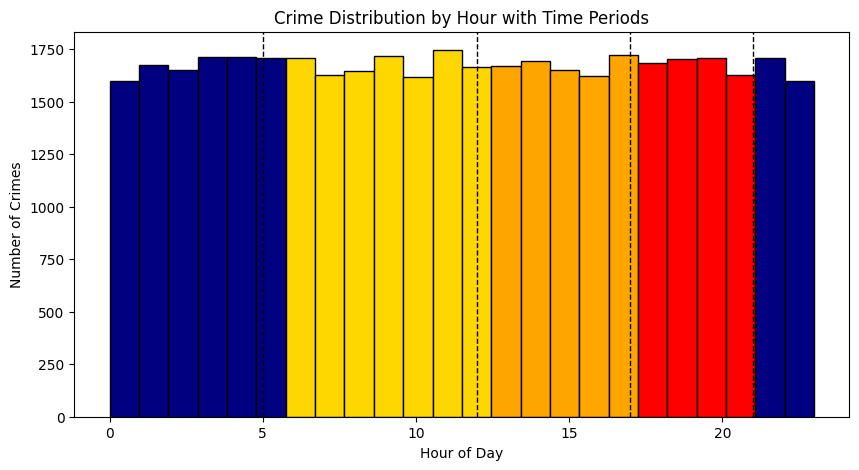

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/crime_dataset_india.csv")

df['Crime Hour'] = pd.to_datetime(
    df['Time of Occurrence'],
    dayfirst=True,
    format='mixed',
    errors='coerce'
).dt.hour

plt.figure(figsize=(10,5))

# Plot histogram
counts, bins, patches = plt.hist(df['Crime Hour'], bins=24, edgecolor='black')

# Color bars based on time range
for i, patch in enumerate(patches):
    hour = bins[i]

    if 5 <= hour < 12:
        patch.set_facecolor('gold')        # Morning
    elif 12 <= hour < 17:
        patch.set_facecolor('orange')      # Afternoon
    elif 17 <= hour < 21:
        patch.set_facecolor('red')         # Evening
    else:
        patch.set_facecolor('navy')        # Night

# Add vertical boundaries
plt.axvline(5, color='black', linestyle='--', linewidth=1)
plt.axvline(12, color='black', linestyle='--', linewidth=1)
plt.axvline(17, color='black', linestyle='--', linewidth=1)
plt.axvline(21, color='black', linestyle='--', linewidth=1)

plt.title("Crime Distribution by Hour with Time Periods")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Crimes")

plt.show()

Insight:
Crime is not limited to a specific hour, meaning criminal activity is continuous across the day rather than concentrated at one exact time.

Interpretation:

•	Law enforcement cannot focus on only one hour window.

•	Crime prevention strategies must cover all time periods.


#

### Crime count by City

In [ ]:
import pandas as pd
import plotly.express as px

# Get crime counts per city
city_counts = df['City'].value_counts().reset_index()
city_counts.columns = ['City', 'Crime Count']

# Interactive bar chart
fig = px.bar(
    city_counts,
    x='Crime Count',
    y='City',
    orientation='h',
    text='Crime Count',
    title='Crime Distribution by City',
    color='Crime Count',
    color_continuous_scale='viridis'
)

# Improve layout
fig.update_layout(
    height=900,
    yaxis={'categoryorder':'total ascending'}
)

fig.show()

Insights:-

1.Delhi has the maximum crime count value(5400).It has massive gap from even 2nd place Mumbai(4415 crimes).

2.Bengaluru has a crime count of 3588.

3.Major crime areas are Mumbai,Delhi,Bengaluru.

4.There is strict crime control in Varanasi,Faribad,Rajkot,Nashik,Srinagar,Vasai and Meerut.

### Top 5 crime Types in Delhi

In [ ]:
import plotly.express as px

delhi = df[df['City'] == 'Delhi']

top5_delhi = delhi['Crime Description'].value_counts().head(5).reset_index()
top5_delhi.columns = ['Crime Type', 'Count']

fig = px.bar(
    top5_delhi,
    x='Count',
    y='Crime Type',
    orientation='h',
    text='Count',
    title="Top 5 Crime Types in Delhi",
    color='Count',
    color_continuous_scale='Reds'
)

fig.update_layout(
    yaxis=dict(categoryorder='total ascending')
)

fig.show()

### Top 5 Crime Types in Mumbai

In [ ]:
import plotly.express as px

mumbai = df[df['City'] == 'Mumbai']

top5_mumbai = mumbai['Crime Description'].value_counts().head(5).reset_index()
top5_mumbai.columns = ['Crime Type', 'Count']

fig = px.bar(
    top5_mumbai,
    x='Count',
    y='Crime Type',
    orientation='h',
    text='Count',
    title="Top 5 Crime Types in Mumbai",
    color='Count',
    color_continuous_scale='Reds'
)

fig.update_layout(
    yaxis=dict(categoryorder='total ascending')
)

fig.show()

### Top 5 crime types In Bengaluru

In [ ]:
import plotly.express as px

bangalore = df[df['City'] == 'Bangalore']

top5_bangalore = bangalore['Crime Description'].value_counts().head(5).reset_index()
top5_bangalore.columns = ['Crime Type', 'Count']

fig = px.bar(
    top5_bangalore,
    x='Count',
    y='Crime Type',
    orientation='h',
    text='Count',
    title="Top 5 Crime Types in Bangalore",
    color='Count',
    color_continuous_scale='Reds'
)

fig.update_layout(
    yaxis=dict(categoryorder='total ascending')
)

fig.show()

1. Delhi:
The most common crime types reported in Delhi include firearm offenses (291 cases), cybercrime (286 cases), fraud (281 cases), along with robbery and drug-related offenses. This indicates that both violent crimes and technology-related crimes are significant concerns in the city.

2. Mumbai:
Mumbai records a notable number of sexual assault cases (243 cases), making it one of the most serious crime categories in the city. Other frequently reported crimes include illegal possession (229 cases) and fraud (227 cases), suggesting concerns related to both public safety and financial crimes.

3. Bengaluru:
In Bengaluru, intoxication-related cases (198 cases) are among the most common offenses reported by the police. Other significant crime categories include extortion (188 cases) and fraud (187 cases), indicating issues related to substance abuse and financial crimes in the region.


A notable observation is that fraud consistently appears among the top crime types in all three cities, highlighting the growing concern of financial and cyber-related criminal activities in metropolitan regions.

### Crime Distrbution By Victim Gender

In [ ]:
import plotly.express as px

gender_counts = df['Victim Gender'].value_counts().reset_index()
gender_counts.columns = ['Victim Gender', 'Count']

fig = px.pie(
    gender_counts,
    names='Victim Gender',
    values='Count',
    color='Victim Gender',
    title="Crime Count by Victim Gender"
)

fig.update_traces(textinfo='percent+label', textposition='inside')

fig.show()

Insight- More than half of the crimes have been committed against women(55.8%)

### Crime Count with Weapons used

In [ ]:
import plotly.express as px

# Filter crimes where a weapon was used
weapon_df = df[df['Weapon Used'] != 'None']

# Count distribution
weapon_counts = weapon_df['Weapon Used'].value_counts().reset_index()
weapon_counts.columns = ['Weapon Used', 'Count']

# Pie chart
fig = px.pie(
    weapon_counts,
    names='Weapon Used',
    values='Count',
    title='Crime Distribution by Weapon Used (Excluding None)',
)

fig.show()

Unexpectedly,the weapons used variable has an equal distribution 😆

### Top crime Types affecting Female Gender

In [ ]:
import plotly.express as px

female = df[df['Victim Gender'] == 'F']

top5_female = female['Crime Description'].value_counts().head(5).reset_index()
top5_female.columns = ['Crime Type', 'Count']

fig = px.bar(
    top5_female,
    x='Count',
    y='Crime Type',
    orientation='h',
    text='Count',
    title="Top 5 Crime Types affecting Females",
    color='Count',
    color_continuous_scale='Blues'
)

fig.update_layout(
    yaxis=dict(categoryorder='total ascending')
)

fig.show()

The analysis of crimes involving female victims shows that Vandalism is the most frequently reported crime, with 1144 cases. This is followed by Fraud (1102 cases) and Burglary (1094 cases). Other significant crimes include Robbery (1084 cases) and Assault (1082 cases).

The relatively small difference in counts among these crime types indicates that multiple categories of crime significantly impact women, rather than a single dominant crime type.

### Analyzing Report Delay

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/crime_dataset_india.csv")
# Date Reported → DD-MM-YYYY
df['Date Reported'] = pd.to_datetime(
    df['Date Reported'],
    dayfirst=True,
    errors='coerce'
)

# Date of Occurrence → MM-DD-YYYY
df['Date of Occurrence'] = pd.to_datetime(
    df['Date of Occurrence'],
    dayfirst=False,
    errors='coerce'
)
df['Report Delay'] = (df['Date Reported'] - df['Date of Occurrence']).dt.days
print("Minimum Report Delay:", df['Report Delay'].min())
print("Maximum Report Delay:", df['Report Delay'].max())
print("Average Report Delay:", df['Report Delay'].mean())
print(df['Report Delay'].head(15))


Minimum Report Delay: 0
Maximum Report Delay: 2
Average Report Delay: 1.0154382470119523
0     1
1     0
2     1
3     0
4     0
5     0
6     0
7     1
8     2
9     1
10    1
11    1
12    0
13    1
14    0
Name: Report Delay, dtype: int64


In [ ]:
import pandas as pd
import plotly.express as px
df = pd.read_csv("/content/crime_dataset_india.csv")
# Date Reported → DD-MM-YYYY
df['Date Reported'] = pd.to_datetime(
    df['Date Reported'],
    dayfirst=True,
    errors='coerce'
)

# Date of Occurrence → MM-DD-YYYY
df['Date of Occurrence'] = pd.to_datetime(
    df['Date of Occurrence'],
    dayfirst=False,
    errors='coerce'
)
df['Report Delay'] = (df['Date Reported'] - df['Date of Occurrence']).dt.days
# Get crime counts per city
report_counts = df['Report Delay'].value_counts().reset_index()
report_counts.columns = ['Report Delay', 'Crime Count']

fig = px.bar(
    report_counts,
    x='Report Delay',
    y='Crime Count',
    text='Crime Count',
    title='Crime Distribution by Report Delay',
    color='Crime Count',
    color_continuous_scale='viridis'
)

fig.update_layout(height=500)

fig.show()

### Case Closed(Yes/No) for 2 days report Delay

In [ ]:
import plotly.express as px

delay_2 = df[df['Report Delay'] == 2]

case_counts = delay_2['Case Closed'].value_counts(normalize=True).reset_index()
case_counts.columns = ['Case Closed','Percentage']

case_counts['Percentage'] = case_counts['Percentage'] * 100

fig = px.bar(
    case_counts,
    x='Case Closed',
    y='Percentage',
    text=case_counts['Percentage'].round(1).astype(str) + '%',
    color='Case Closed',
    title='Case Closure Rate for Crimes Reported After 2 Days'
)

fig.update_layout(
    yaxis_title="Percentage of Cases",
    xaxis_title="Case Status",
    yaxis=dict(range=[0,100]),
    height=450
)

fig.show()

INSIGHT- Crimes reported after a delay of two days show almost an equal probability of being solved or remaining unsolved. This suggests that a reporting delay of two days may impact investigation success.

Therefore,it is advised to report crimes immediately

INSIGHT-As we can see,about 36% in Kolkata report crimes with a delay of 2 days,probably because of severity of the crimes or repeated threats.

In [ ]:
import plotly.express as px
import pandas as pd
import plotly.express as px
df = pd.read_csv("/content/crime_dataset_india.csv")
# Date Reported → DD-MM-YYYY
df['Date Reported'] = pd.to_datetime(
    df['Date Reported'],
    dayfirst=True,
    errors='coerce'
)

# Date of Occurrence → MM-DD-YYYY
df['Date of Occurrence'] = pd.to_datetime(
    df['Date of Occurrence'],
    dayfirst=False,
    errors='coerce'
)
df['Report Delay'] = (df['Date Reported'] - df['Date of Occurrence']).dt.days
cities = ['Chennai','Hyderabad','Kolkata','Pune','Lucknow']

# Filter dataset
filtered_df = df[
    (df['City'].isin(cities)) &
    (df['Report Delay'].isin([0,1,2]))
]

# Count crimes
counts = (
    filtered_df
    .groupby(['City','Report Delay'])
    .size()
    .reset_index(name='Crime Count')
)

# Plot grouped bar chart
fig = px.bar(
    counts,
    x='City',
    y='Crime Count',
    color='Report Delay',
    barmode='group',
    text='Crime Count',
    title='Crime Counts by Report Delay (0,1,2) for Selected Cities'
)

fig.update_layout(
    height=500
)

fig.show()

INSIGHT-As we can see,about 36% in Kolkata report crimes with a delay of 2 days,probably because of severity of the crimes or repeated threats.

In [ ]:
import pandas as pd
import plotly.express as px
df = pd.read_csv("/content/crime_dataset_india.csv")

import plotly.express as px

kolkata= df[df['City'] == 'Kolkata']

top5_kolkata = kolkata['Crime Description'].value_counts().head(10).reset_index()
top5_kolkata.columns = ['Crime Type', 'Count']

fig = px.bar(
    top5_kolkata,
    x='Count',
    y='Crime Type',
    orientation='h',
    text='Count',
    title="Top 10 Crime Types in Kolkata",
    color='Count',
    color_continuous_scale='Reds'
)

fig.update_layout(
    yaxis=dict(categoryorder='total ascending')
)

fig.show()

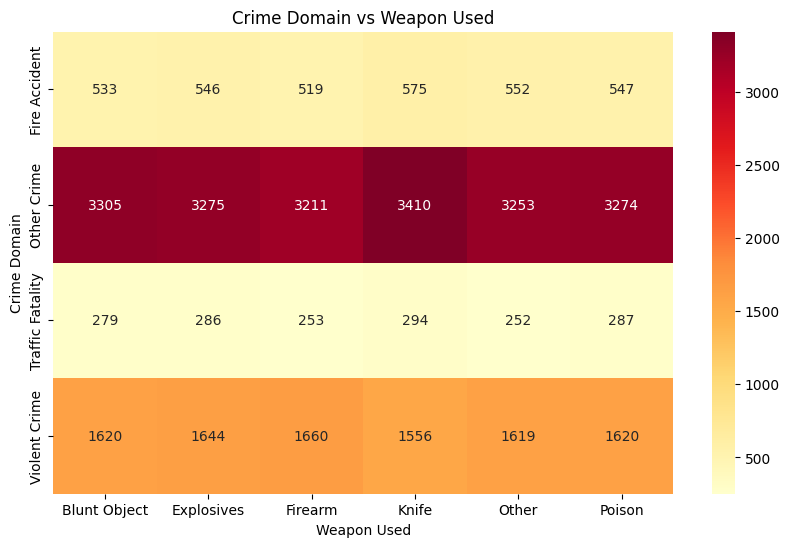

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
df = pd.read_csv("/content/crime_dataset_india.csv")

# Create cross-tabulation
cross_tab = pd.crosstab(df['Crime Domain'], df['Weapon Used'])

plt.figure(figsize=(10,6))

sns.heatmap(
    cross_tab,
    annot=True,
    fmt='d',
    cmap='YlOrRd'
)

plt.title("Crime Domain vs Weapon Used")
plt.xlabel("Weapon Used")
plt.ylabel("Crime Domain")

plt.show()

### Crime Resolution Status

In [ ]:
import plotly.express as px

# Get counts
case_counts = df['Case Closed'].value_counts().reset_index()
case_counts.columns = ['Case Closed', 'Count']

# Plot interactive bar chart
fig = px.bar(
    case_counts,
    x='Case Closed',
    y='Count',
    text='Count',
    color='Case Closed',
    title='Crime Resolution Distribution'
)

fig.update_layout(
    xaxis_title='Case Closed',
    yaxis_title='Number of Cases'
)

fig.show()

### Crime Resolution rate for certain areas

In [ ]:
import pandas as pd
import plotly.express as px

# Select required cities
selected_cities = ['Delhi','Mumbai','Vishakhapatnam','Ghaziabad','Nagpur','Kolkata','Kanpur','Surat','Ghaziabad','Hyderabad']

df_filtered = df[df['City'].isin(selected_cities)]

# Group data
city_case = df_filtered.groupby(['City', 'Case Closed']).size().reset_index(name='Count')

# Plot
fig = px.bar(
    city_case,
    x='City',
    y='Count',
    color='Case Closed',
    text='Count',
    title='Case Closed (Yes/No) Distribution Across Selected Cities',
    color_discrete_map={'Yes':'green', 'No':'red'}
)

# Stacked bars
fig.update_layout(
    barmode='stack',
    xaxis_title='City',
    yaxis_title='Number of Cases'
)

fig.show()

### Top cities with highest case closure

In [ ]:
import pandas as pd

# Total cases per city
total_cases = df.groupby('City').size()

# Closed cases per city
closed_cases = df[df['Case Closed'] == 'Yes'].groupby('City').size()

# Combine into one dataframe
accuracy_df = pd.DataFrame({
    'Total Cases': total_cases,
    'Closed Cases': closed_cases
}).fillna(0)

# Calculate percentage
accuracy_df['Closure %'] = (accuracy_df['Closed Cases'] / accuracy_df['Total Cases']) * 100

# Sort and get top 5
top5_cities = accuracy_df.sort_values(by='Closure %', ascending=False).head(5).reset_index()

top5_cities

,City,Total Cases,Closed Cases,Closure %
0,Thane,706,379,53.682720
1,Ludhiana,761,403,52.956636
2,Faridabad,354,187,52.824859
3,Rajkot,320,165,51.562500
4,Kanpur,1112,571,51.348921


In [ ]:
import plotly.express as px

fig = px.bar(
    top5_cities,
    x='City',
    y='Closure %',
    text=top5_cities['Closure %'].round(2),
    color='Closure %',
    color_continuous_scale='viridis',
    title='Top 5 Cities with Highest Case Closure Rate (%)'
)

fig.update_layout(
    xaxis_title='City',
    yaxis_title='Closure Percentage'
)

fig.show()

### Top 5 cities with lowest Case Solved

In [ ]:
import pandas as pd

# Total cases per city
total_cases = df.groupby('City').size()

# Closed cases per city
closed_cases = df[df['Case Closed'] == 'Yes'].groupby('City').size()

# Combine into one dataframe
accuracy_df = pd.DataFrame({
    'Total Cases': total_cases,
    'Closed Cases': closed_cases
}).fillna(0)

# Calculate percentage
accuracy_df['Closure %'] = (accuracy_df['Closed Cases'] / accuracy_df['Total Cases']) * 100

# Sort and get top 5
top5_cities = accuracy_df.sort_values(by='Closure %', ascending=False).tail(5).reset_index()

top5_cities

,City,Total Cases,Closed Cases,Closure %
0,Nashik,366,175,47.814208
1,Vasai,362,172,47.513812
2,Meerut,395,187,47.341772
3,Kalyan,355,165,46.478873
4,Srinagar,371,166,44.743935


In [ ]:
import plotly.express as px

fig = px.bar(
    top5_cities,
    x='City',
    y='Closure %',
    text=top5_cities['Closure %'].round(2),
    color='Closure %',
    color_continuous_scale='viridis',
    title='Top 5 Cities with Lowest Case Closure Rate (%)'
)

fig.update_layout(
    xaxis_title='City',
    yaxis_title='Closure Percentage'
)

fig.show()

According to the graph,Srinagar has very low case closure rate(about 44% of the cases get solved).Other underperforming cities include Meerut,Vasai,Kalyan and Nashik.

However,we know that all these cities have very less crime,less than 400 cases,so this shouldn't be a problem unless crime rate gets higher.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
df = pd.read_csv("/content/crime_dataset_india.csv")
def crime_period(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"
df['Crime Hour'] = pd.to_datetime(df['Time of Occurrence'], dayfirst=True, format='mixed', errors='coerce').dt.hour
df['Crime Period'] = df['Crime Hour'].apply(crime_period)
period_case = pd.crosstab(df['Crime Period'], df['Case Closed'], normalize='index').reset_index()

fig = px.bar(
    period_case,
    x='Crime Period',
    y=['Yes','No'],
    title='Case Closure by Time of Day'
)

fig.update_layout(barmode='stack')
fig.show()

### Crime Count by Victim Age

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
age_counts = df['Victim Age'].value_counts().sort_index().reset_index()
age_counts.columns = ['Victim Age', 'Crime Count']

fig = px.bar(
    age_counts,
    x='Victim Age',
    y='Crime Count',
    text='Crime Count',
    title='Crime Count for Each Victim Age'
)

fig.show()

The crime distribution across victim age appears relatively uniform, indicating that age does not significantly influence crime occurrence in this dataset. There is no specific age group that is disproportionately affected.

### Crime Count by Case Duration

In [ ]:
import pandas as pd
import plotly.express as px
df = pd.read_csv("/content/crime_dataset_india.csv")
df['Date Reported'] = pd.to_datetime(df['Date Reported'], dayfirst=True, format='mixed', errors='coerce')
df['Date of Occurrence'] = pd.to_datetime(df['Date of Occurrence'], dayfirst=True, format='mixed', errors='coerce')
df['Date Case Closed'] = pd.to_datetime(df['Date Case Closed'], dayfirst=True, format='mixed', errors='coerce')
df['Case Duration'] = (df['Date Case Closed'] - df['Date Reported']).dt.days
# Get crime counts per case duration
cd_counts = df['Case Duration'].value_counts().reset_index()
cd_counts.columns = ['Case Duration', 'Crime Count']
cd_counts = cd_counts[cd_counts['Case Duration'] <= 200]
fig = px.bar(
    cd_counts,
    x='Case Duration',
    y='Crime Count',
    text='Crime Count',
    title='Crime Distribution by Case Duration',
    color='Crime Count',
    color_continuous_scale='viridis'
)

fig.update_layout(height=500)

fig.show()

In [ ]:
import numpy as np

sorted_df = df['Case Duration'].dropna().sort_values()
cum_percent = np.arange(1, len(sorted_df)+1) / len(sorted_df) * 100

fig = px.line(
    x=sorted_df,
    y=cum_percent,
    title='Cumulative Case Closure Distribution'
)

fig.update_layout(
    xaxis_title='Case Duration (Days)',
    yaxis_title='Cumulative % of Cases'
)

fig.show()

### Tpo cities with highest case durations

In [ ]:
high_duration_df = df[df['Case Duration'] > 60]
city_counts = high_duration_df['City'].value_counts().reset_index()
city_counts.columns = ['City', 'High Duration Cases']
import plotly.express as px

fig = px.bar(
    city_counts.head(10),
    x='City',
    y='High Duration Cases',
    text='High Duration Cases',
    color='High Duration Cases',
    color_continuous_scale='viridis',
    title='Top Cities with High Case Durations (>60 Days)'
)

fig.show()

### Top cities with lowest case durations

In [ ]:
city_duration = df.groupby('City')['Case Duration'].mean().reset_index()
city_duration.columns = ['City', 'Avg Case Duration']
top_fast_cities = city_duration.sort_values(by='Avg Case Duration').head(10)
import plotly.express as px

fig = px.bar(
    top_fast_cities,
    x='City',
    y='Avg Case Duration',
    text=top_fast_cities['Avg Case Duration'].round(1),
    color='Avg Case Duration',
    color_continuous_scale='viridis',
    title='Top Cities with Lowest Average Case Duration'
)

fig.show()

1.Cities with highest case durations are Delhi,Mumbai,Bengaluru and Hyderabad,showing slower case resolution

2.Cities with lowest case durations are Varanasi,Faridabad,Kanpur,Nagpur and Surat,showing faster case resolution.

In [ ]:
high_duration_df = df[df['Case Duration'] > 60]
cities_df = high_duration_df[high_duration_df['City'].isin(['Delhi', 'Mumbai'])]
crime_counts = cities_df.groupby(['City', 'Crime Description']).size().reset_index(name='Count')
top_crimes = crime_counts.sort_values(['City', 'Count'], ascending=[True, False])
top_crimes = top_crimes.groupby('City').head(10)
import plotly.express as px

fig = px.bar(
    top_crimes,
    x='Crime Description',
    y='Count',
    color='City',
    facet_col='City',
    text='Count',
    title='Top 10 High Duration Crimes (>60 Days) in Delhi vs Mumbai'
)

fig.update_layout(
    xaxis_tickangle=-45,
    height=500
)

fig.show()

1.Major high duration crimes in Delhi include homicide,sexual assault,robbery and burglary.Other crimes are arson,cyber crime and kidnapping.

2.Major crimes in Mumbai also include homicide,sexual assault,robbery,burglary.Others include shoplifting and fraud.

### Monthly Crime Trend

In [ ]:
import pandas as pd
import plotly.express as px

# Ensure datetime format
df['Date Reported'] = pd.to_datetime(df['Date Reported'], errors='coerce')

# Create Year-Month column
df['Year-Month'] = df['Date Reported'].dt.to_period('M').astype(str)

# Group by month
monthly_trend = df.groupby('Year-Month').size().reset_index(name='Crime Count')

# Plot
fig = px.line(
    monthly_trend,
    x='Year-Month',
    y='Crime Count',
    markers=True,
    title='Monthly Crime Trend'
)

fig.update_layout(height=500)

fig.show()

### City Wise Crime Trend

In [ ]:
# Select cities (you can modify this list)
cities = ['Delhi','Mumbai','Bengaluru']

# Filter + group
city_trend = (
    df[df['City'].isin(cities)]
    .groupby(['Year-Month','City'])
    .size()
    .reset_index(name='Crime Count')
)

# Plot
fig = px.line(
    city_trend,
    x='Year-Month',
    y='Crime Count',
    color='City',
    markers=True,
    title='City-wise Crime Trend'
)

fig.update_layout(height=500)

fig.show()

1.There are certain periods of High criminal activity in Mumbai(Mar-July 2022) and Mar 2023-Jan 2024.

2.It was reported that street crimes such as theft,molestation and attacks rose in Mumbai by 100% in 2022.(Post COVID)

3.Mumbai recorded highest econmoic fraud cases among Metros in 2023

In [ ]:
# Select cities (you can modify this list)
cities = ['Delhi','Bangalore']
import pandas as pd
import plotly.express as px

# Ensure datetime format
df['Date Reported'] = pd.to_datetime(df['Date Reported'], errors='coerce')

# Create Year-Month column
df['Year-Month'] = df['Date Reported'].dt.to_period('M').astype(str)

# Group by month
monthly_trend = df.groupby('Year-Month').size().reset_index(name='Crime Count')
# Filter + group
city_trend = (
    df[df['City'].isin(cities)]
    .groupby(['Year-Month','City'])
    .size()
    .reset_index(name='Crime Count')
)

# Plot
fig = px.line(
    city_trend,
    x='Year-Month',
    y='Crime Count',
    color='City',
    markers=True,
    title='City-wise Crime Trend'
)

fig.update_layout(height=500)

fig.show()


### K Means Clustering

In [ ]:
import pandas as pd

# Select useful columns
df_model = df[[
    'Report Delay',
    'Case Duration',
    'City',
    'Victim Gender',
    'Weapon Used',
    'Crime Domain'
]].copy()
df_model['Weapon Used'] = df_model['Weapon Used'].fillna('Unknown')
df_model.dropna(inplace=True)
df_encoded = pd.get_dummies(
    df_model,
    columns=['City','Victim Gender','Weapon Used','Crime Domain'],
    drop_first=True
)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_encoded)
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')

df_clustered = df_model.copy()
df_clustered['Cluster'] = kmeans.fit_predict(scaled_features)
print(df_clustered.groupby('Cluster')[['Report Delay','Case Duration']].mean())
for i in range(4):
    print(f"\nCluster {i} - Top Cities:")
    print(df_clustered[df_clustered['Cluster']==i]['City'].value_counts().head(5))
for i in range(4):
    print(f"\nCluster {i} - Crime Domains:")
    print(df_clustered[df_clustered['Cluster']==i]['Crime Domain'].value_counts())
for i in range(4):
    print(f"\nCluster {i} - Gender:")
    print(df_clustered[df_clustered['Cluster']==i]['Victim Gender'].value_counts())

         Report Delay  Case Duration
Cluster                             
0            1.007570      74.932148
1            1.037086      83.733775
2            1.021005      75.927335
3            1.012036     127.469184

Cluster 0 - Top Cities:
City
Delhi        1613
Mumbai       1338
Bangalore    1094
Hyderabad     878
Chennai       746
Name: count, dtype: int64

Cluster 1 - Top Cities:
City
Jaipur    755
Name: count, dtype: int64

Cluster 2 - Top Cities:
City
Kolkata      960
Delhi        362
Mumbai       311
Bangalore    227
Hyderabad    202
Name: count, dtype: int64

Cluster 3 - Top Cities:
City
Delhi        671
Mumbai       552
Bangalore    438
Hyderabad    379
Kolkata      307
Name: count, dtype: int64

Cluster 0 - Crime Domains:
Crime Domain
Other Crime         8791
Fire Accident       1457
Traffic Fatality     717
Name: count, dtype: int64

Cluster 1 - Crime Domains:
Crime Domain
Other Crime         428
Violent Crime       215
Fire Accident        67
Traffic Fatality     45
N

Cluster 3



*   Significantly higher average case duration(65 days),with many cases going over 100 days
*   Only violent crime cases
*   Such crimes require longer crime investigation
*   Females highly affected





In [ ]:
import plotly.express as px

# Interactive boxplot
fig = px.box(
    df_clustered,
    x='Cluster',
    y='Case Duration',
    title='Case Duration Distribution by Cluster',
    points=False   # shows all data points
)
fig.update_yaxes(type="linear")
fig.show()

In [ ]:
from sklearn.decomposition import PCA
import plotly.express as px

pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

df_clustered['PCA1'] = pca_features[:,0]
df_clustered['PCA2'] = pca_features[:,1]

fig = px.scatter(
    df_clustered,
    x='PCA1',
    y='PCA2',
    color='Cluster',
    title='Crime Clusters (PCA Visualization)'
)

fig.show()

Key Insights from K-Means + PCA

•	Distinct Violent Crime Cluster:
A clearly separable cluster represents violent crimes, characterized by significantly higher case duration (127 days). PCA confirms strong separation, indicating fundamentally different behavior.

•	Overlapping General Crime Patterns:
Other clusters show substantial overlap, suggesting that most crimes share similar characteristics in terms of duration and reporting behavior.

•	Minimal Impact of Report Delay:
Report delay remains consistent (1 day) across all clusters, indicating it does not significantly influence crime differentiation.

•	City-Level Variations:
Major cities (Delhi, Mumbai, Bangalore) dominate multiple clusters, while some cities (e.g., Jaipur) exhibit localized patterns.

•	Hidden Sub-Patterns:
PCA reveals minor sub-groupings within overlapping clusters, suggesting subtle influences of city or crime type,but not strong enough to leave the cluster


# ML MODELS

In [ ]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("/content/crime_dataset_india.csv")

# Convert dates
df['Date Reported'] = pd.to_datetime(df['Date Reported'], dayfirst=True, errors='coerce')
df['Date of Occurrence'] = pd.to_datetime(df['Date of Occurrence'], dayfirst=True, errors='coerce')
df['Date Case Closed'] = pd.to_datetime(df['Date Case Closed'], dayfirst=True, errors='coerce')

# Feature Engineering
df['Crime Hour'] = pd.to_datetime(df['Time of Occurrence'], errors='coerce').dt.hour

def crime_period(hour):
    if pd.isna(hour):
        return np.nan
    elif 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df['Crime Period'] = df['Crime Hour'].apply(crime_period)

df['Report Delay'] = (df['Date Reported'] - df['Date of Occurrence']).dt.days

# =========================
# 🔥 DEFINE MODEL DATA (NO CASE DURATION)
# =========================
df_model = df[[
    'Crime Period',
    'City',
    'Victim Age',
    'Crime Description',
    'Police Deployed',
    'Weapon Used',
    'Report Delay',
    'Crime Domain',
    'Case Closed'

]].copy()

# =========================
# HANDLE MISSING VALUES
# ========================
df_model['Weapon Used'] = df_model['Weapon Used'].fillna('Unknown')
df_model['Report Delay'] = df_model['Report Delay'].fillna(0)

df_model.dropna(inplace=True)

# =========================
# REDUCE HIGH CARDINALITY (TOP 20 CRIMES)
# =========================
top_crimes = df_model['Crime Description'].value_counts().head(15).index

df_model['Crime Description'] = df_model['Crime Description'].apply(
    lambda x: x if x in top_crimes else 'Other'
)

# =========================
# TARGET ENCODING
# =========================
df_model['Case Closed'] = df_model['Case Closed'].map({'Yes':1, 'No':0})

# =========================
# ONE HOT ENCODING
# =========================
df_encoded = pd.get_dummies(
    df_model,
    columns=[
        'Crime Period',
        'City',
        'Crime Description',
        'Police Deployed',
        'Crime Domain',
        'Weapon Used'
    ],
    drop_first=True
)

# =========================
# SPLIT DATA
# =========================
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Case Closed', axis=1)
y = df_encoded['Case Closed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# =========================
# 🌳 Decision Tree Model
# =========================

# =========================
# 🌳 IMPROVED DECISION TREE (TUNED)
# =========================

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================
# 🔹 Stratified Split (VERY IMPORTANT)
# =========================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # 🔥 keeps class balance
)

# =========================
# 🔹 Hyperparameter Grid
# =========================
param_grid = {
    'max_depth': [5, 8, 12, 15],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 20],
    'criterion': ['gini', 'entropy']
}

# =========================
# 🔹 Grid Search
# =========================
dt = DecisionTreeClassifier(random_state=42)

grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=10,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

# Best model
best_dt = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

# =========================
# 🔹 Predictions
# =========================
y_pred_dt = best_dt.predict(X_test)

# =========================
# 📊 Evaluation
# =========================
print("\nDecision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Best Parameters: {'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 20, 'min_samples_split': 5}

Decision Tree Accuracy: 0.5022109917877448

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.91      0.65      1599
           1       0.48      0.08      0.14      1567

    accuracy                           0.50      3166
   macro avg       0.49      0.50      0.39      3166
weighted avg       0.49      0.50      0.40      3166


Confusion Matrix:
 [[1463  136]
 [1440  127]]


In [ ]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("/content/crime_dataset_india.csv")

# Convert dates
df['Date Reported'] = pd.to_datetime(df['Date Reported'], dayfirst=True, errors='coerce')
df['Date of Occurrence'] = pd.to_datetime(df['Date of Occurrence'], dayfirst=True, errors='coerce')
df['Date Case Closed'] = pd.to_datetime(df['Date Case Closed'], dayfirst=True, errors='coerce')

# Feature Engineering
df['Crime Hour'] = pd.to_datetime(df['Time of Occurrence'], errors='coerce').dt.hour

def crime_period(hour):
    if pd.isna(hour):
        return np.nan
    elif 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df['Crime Period'] = df['Crime Hour'].apply(crime_period)

df['Report Delay'] = (df['Date Reported'] - df['Date of Occurrence']).dt.days

# =========================
# 🔥 DEFINE MODEL DATA (NO CASE DURATION)
# =========================
df_model = df[[
    'Crime Period',
    'City',
    'Victim Age',
    'Crime Description',
    'Weapon Used',
    'Police Deployed',
    'Report Delay',
    'Victim Gender',
    'Case Closed'
]].copy()

# =========================
# HANDLE MISSING VALUES
# =========================
df_model['Weapon Used'] = df_model['Weapon Used'].fillna('Unknown')
df_model['Report Delay'] = df_model['Report Delay'].fillna(0)

df_model.dropna(inplace=True)

# =========================
# REDUCE HIGH CARDINALITY (TOP 20 CRIMES)
# =========================
top_crimes = df_model['Crime Description'].value_counts().head(20).index

df_model['Crime Description'] = df_model['Crime Description'].apply(
    lambda x: x if x in top_crimes else 'Other'
)

# =========================
# TARGET ENCODING
# =========================
df_model['Case Closed'] = df_model['Case Closed'].map({'Yes':1, 'No':0})

# =========================
# ONE HOT ENCODING
# =========================
df_encoded = pd.get_dummies(
    df_model,
    columns=[
        'Crime Period',
        'City',
        'Crime Description',
        'Weapon Used',
        'Victim Gender'
    ],
    drop_first=True
)

# =========================
# SPLIT DATA
# =========================
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Case Closed', axis=1)
y = df_encoded['Case Closed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# MODEL
# =========================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

# =========================
# OUTPUT
# =========================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.5009475679090335

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.60      0.55      1599
           1       0.49      0.40      0.44      1567

    accuracy                           0.50      3166
   macro avg       0.50      0.50      0.50      3166
weighted avg       0.50      0.50      0.50      3166


Confusion Matrix:
 [[960 639]
 [941 626]]


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Model
rf = RandomForestClassifier(random_state=42)

# Parameter distribution (smaller but effective)
param_dist = {
    'n_estimators': [100, 150, 200],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt'],
    'bootstrap': [True, False]
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,          # only 20 combinations (FAST)
    cv=5,               # reduced from 10 → 5
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1           # shows progress
)

# Fit
random_search.fit(X_train, y_train)

# Best model
best_rf = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)

# Predictions
y_pred_rf = best_rf.predict(X_test)

# Evaluation
print("\nRandom Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': True}

Random Forest Accuracy: 0.4933670246367656

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.63      0.56      1599
           1       0.48      0.35      0.41      1567

    accuracy                           0.49      3166
   macro avg       0.49      0.49      0.48      3166
weighted avg       0.49      0.49      0.48      3166


Confusion Matrix:
 [[1010  589]
 [1015  552]]


In [ ]:
import pandas as pd

importance = pd.Series(best_rf.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False).head(15))

Report Delay                  0.140479
Victim Age                    0.132270
Crime Period_Morning          0.020235
Crime Period_Night            0.018730
Weapon Used_Poison            0.018373
Weapon Used_Other             0.017491
Weapon Used_Explosives        0.017026
Weapon Used_Unknown           0.016738
Weapon Used_Knife             0.016609
Crime Period_Evening          0.016522
Weapon Used_Firearm           0.015944
Crime Description_Other       0.015271
Crime Domain_Other Crime      0.014336
Crime Domain_Violent Crime    0.013016
City_Mumbai                   0.012395
dtype: float64


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Model
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# Train
xgb.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb.predict(X_test)

# Evaluation
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

XGBoost Accuracy: 0.49912848605577687

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.50      0.50      4020
           1       0.50      0.50      0.50      4012

    accuracy                           0.50      8032
   macro avg       0.50      0.50      0.50      8032
weighted avg       0.50      0.50      0.50      8032


Confusion Matrix:
 [[2020 2000]
 [2023 1989]]


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================
# 🔥 BASE MODEL
# =========================
xgb = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)

# =========================
# 🔥 IMPROVED PARAM GRID
# =========================
param_dist = {
    'n_estimators': [300, 500, 800, 1000],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'min_child_weight': [1, 3, 5, 7],
    'reg_alpha': [0, 0.1, 1],        # L1 regularization
    'reg_lambda': [1, 2, 5]          # L2 regularization
}

# =========================
# 🔥 RANDOM SEARCH
# =========================
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=40,                # more search power
    scoring='accuracy',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# =========================
# 🔥 FIT MODEL
# =========================
random_search.fit(X_train, y_train)

best_xgb = random_search.best_estimator_

# =========================
# 🔥 PREDICTIONS
# =========================
y_pred = best_xgb.predict(X_test)

# =========================
# 📊 EVALUATION
# =========================
print("Best Parameters:", random_search.best_params_)

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Fitting 5 folds for each of 40 candidates, totalling 200 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:25:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 1000, 'min_child_weight': 7, 'max_depth': 10, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.7}

Accuracy: 0.7678458622867972

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.50      0.67       301
           1       0.71      1.00      0.83      1805
           2       0.00      0.00      0.00       148
           3       1.00      0.52      0.68       912

    accuracy                           0.77      3166
   macro avg       0.68      0.51      0.55      3166
weighted avg       0.79      0.77      0.73      3166


Confusion Matrix:
 [[ 151  150    0    0]
 [   0 1805    0    0]
 [   0  148    0    0]
 [   0  437    0  475]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


After SMOTE:
 1    7216
0    7216
2    7216
3    7216
Name: count, dtype: int64
Accuracy: 0.7580543272267846

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.50      0.66       301
           1       0.73      0.95      0.82      1805
           2       0.20      0.02      0.04       148
           3       0.85      0.58      0.69       912

    accuracy                           0.76      3166
   macro avg       0.68      0.51      0.55      3166
weighted avg       0.76      0.76      0.73      3166


Confusion Matrix:



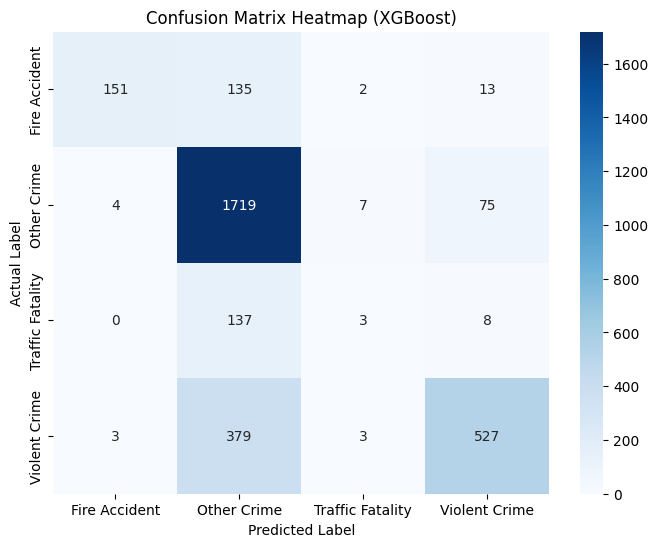


Actual Distribution:
 1    1805
3     912
0     301
2     148
Name: count, dtype: int64

Predicted Distribution:
 1    2370
3     623
0     158
2      15
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("/content/crime_dataset_india.csv")

# =========================
# DATE CONVERSION
# =========================
df['Date Reported'] = pd.to_datetime(df['Date Reported'], dayfirst=True, errors='coerce')
df['Date of Occurrence'] = pd.to_datetime(df['Date of Occurrence'], dayfirst=True, errors='coerce')

# =========================
# FEATURE ENGINEERING
# =========================
df['Crime Hour'] = pd.to_datetime(df['Time of Occurrence'], errors='coerce').dt.hour

df['Report Delay'] = (df['Date Reported'] - df['Date of Occurrence']).dt.days

# =========================
# DEFINE MODEL DATA (STRICT)
# =========================
df_model = df[[
    'Crime Hour',
    'City',
    'Victim Age',
    'Crime Description',
    'Police Deployed',
    'Report Delay',
    'Crime Domain'   # TARGET
]].copy()

# =========================
# HANDLE MISSING VALUES
# =========================
df_model['Report Delay'] = df_model['Report Delay'].fillna(0)
df_model.dropna(inplace=True)

# =========================
# REDUCE HIGH CARDINALITY
# =========================
top_crimes = df_model['Crime Description'].value_counts().head(10).index

df_model['Crime Description'] = df_model['Crime Description'].apply(
    lambda x: x if x in top_crimes else 'Other'
)

# =========================
# ENCODE TARGET
# =========================
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df_model['Crime Domain'])

# =========================
# ONE HOT ENCODING (ONLY FEATURES)
# =========================
df_encoded = pd.get_dummies(
    df_model.drop('Crime Domain', axis=1),
    columns=['City', 'Crime Description'],
    drop_first=True
)

X = df_encoded

# =========================
# TRAIN TEST SPLIT (STRATIFIED)
# =========================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
from imblearn.over_sampling import SMOTE

# Apply SMOTE ONLY on training data
smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE:\n", pd.Series(y_train_sm).value_counts())
# =========================
# XGBOOST MODEL
# =========================
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=600,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)

# =========================
# PREDICTIONS
# =========================
y_pred = xgb.predict(X_test)

# =========================
# EVALUATION
# =========================
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Get class labels
labels = le.classes_

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap (XGBoost)")

plt.show()
# =========================
# DEBUG CHECK (VERY IMPORTANT)
# =========================
print("\nActual Distribution:\n", pd.Series(y_test).value_counts())
print("\nPredicted Distribution:\n", pd.Series(y_pred).value_counts())

Accuracy: 0.7353126974099811

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.50      0.62       301
           1       0.74      0.90      0.81      1805
           2       0.14      0.08      0.10       148
           3       0.77      0.59      0.67       912

    accuracy                           0.74      3166
   macro avg       0.62      0.52      0.55      3166
weighted avg       0.73      0.74      0.72      3166



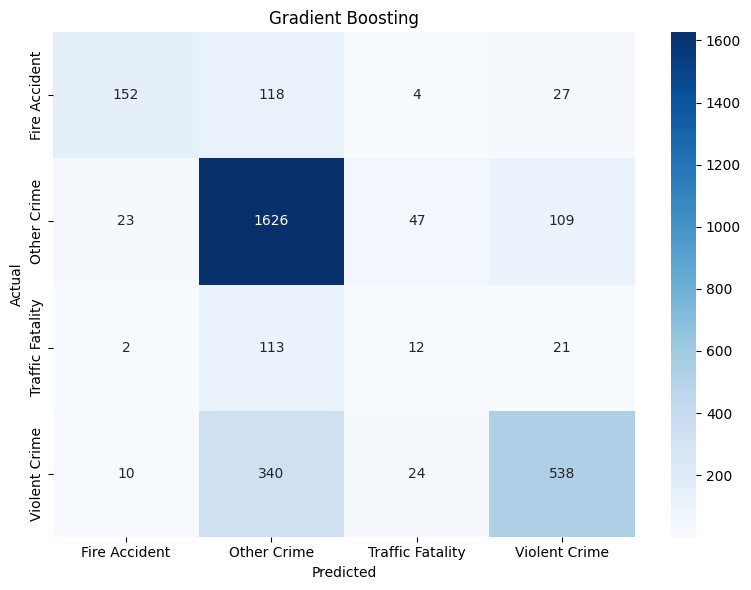

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# LOAD & PREPROCESS (SAME)
# =========================
df = pd.read_csv("/content/crime_dataset_india.csv")
df['Date Reported'] = pd.to_datetime(df['Date Reported'], dayfirst=True, errors='coerce')
df['Date of Occurrence'] = pd.to_datetime(df['Date of Occurrence'], dayfirst=True, errors='coerce')
df['Crime Hour'] = pd.to_datetime(df['Time of Occurrence'], errors='coerce').dt.hour
df['Report Delay'] = (df['Date Reported'] - df['Date of Occurrence']).dt.days

df_model = df[['Crime Hour', 'City', 'Victim Age', 'Crime Description',
               'Police Deployed', 'Report Delay', 'Crime Domain']].copy()
df_model['Report Delay'] = df_model['Report Delay'].fillna(0)
df_model.dropna(inplace=True)
df_model['Crime Description'] = df_model['Crime Description'].apply(
    lambda x: x if x in top_crimes else 'Other')

# Encode target
le = LabelEncoder()
y = le.fit_transform(df_model['Crime Domain'])

# One-hot encode features
df_encoded = pd.get_dummies(df_model.drop('Crime Domain', axis=1),
                           columns=['City', 'Crime Description'], drop_first=True)
X = df_encoded

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                   random_state=42, stratify=y)

# =========================
# 🔥 GRADIENT BOOSTING PIPELINE WITH SMOTE
# =========================
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=3)),  # Handle imbalance
    ('model', GradientBoostingClassifier(
        n_estimators=500,      # More trees than XGBoost
        learning_rate=0.05,    # Slower learning for stability
        max_depth=6,           # Shallower trees
        subsample=0.8,         # Stochastic gradient boosting
        min_samples_split=20,
        min_samples_leaf=10,   # Prevent overfitting
        random_state=42
    ))
])

# Fit pipeline
pipeline.fit(X_train, y_train)

# =========================
# PREDICTIONS & EVALUATION
# =========================
y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [ ]:
# =========================
# 📦 IMPORTS
# =========================
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import numpy as np

# =========================
# 🔥 APPLY SMOTE
# =========================
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# =========================
# 🌳 MODEL
# =========================
dt = DecisionTreeClassifier(random_state=42)

# =========================
# 🔥 STRONG PARAM GRID
# =========================
param_grid = {
    'max_depth': [10, 15, 20, 25],
    'min_samples_split': [10, 20, 40],
    'min_samples_leaf': [5, 10, 20],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': [None, 'balanced']
}

# =========================
# 🔍 GRID SEARCH
# =========================
grid = GridSearchCV(
    dt,
    param_grid,
    cv=5,
    scoring='f1_weighted',   # 🔥 IMPORTANT CHANGE
    n_jobs=-1,
    verbose=1
)

# =========================
# 🔥 TRAIN
# =========================
grid.fit(X_train_smote, y_train_smote)

best_dt = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

# =========================
# 🔥 PREDICT
# =========================
y_pred = best_dt.predict(X_test)

# =========================
# 📊 EVALUATION
# =========================
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best Parameters: {'class_weight': None, 'criterion': 'gini', 'max_depth': 25, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 10}

Accuracy: 0.7274162981680353

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.53      0.62       301
           1       0.74      0.90      0.81      1805
           2       0.13      0.14      0.13       148
           3       0.86      0.55      0.67       912

    accuracy                           0.73      3166
   macro avg       0.61      0.53      0.56      3166
weighted avg       0.74      0.73      0.72      3166


Confusion Matrix:
 [[ 160  123   11    7]
 [  37 1617   81   70]
 [   8  113   20    7]
 [  14  346   46  506]]


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get importance values
importances = xgb.feature_importances_

# Map to feature names
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names)

# Sort
feat_imp = feat_imp.sort_values(ascending=False)

# Print top 10
print("Top 10 Important Features:\n")
print(feat_imp.head(10))

Top 10 Important Features:

Crime Description_FIREARM OFFENSE        0.202235
Crime Description_ROBBERY                0.164036
Crime Description_IDENTITY THEFT         0.134905
Crime Description_DOMESTIC VIOLENCE      0.128668
Crime Description_Other                  0.114533
Crime Description_FRAUD                  0.030327
Crime Description_KIDNAPPING             0.030104
Crime Description_COUNTERFEITING         0.028226
Crime Description_PUBLIC INTOXICATION    0.026217
Crime Description_CYBERCRIME             0.025772
dtype: float32
